# Country Clustering using Unsupervised Learning

## 1. Import Libraries

## 2. Load Dataset

## 3. Data Understanding

## 4. Data Cleaning

## 5. Exploratory Data Analysis

## 6. Feature Scaling

## 7. Finding Optimal Number of Clusters

## 8. K-Means Clustering

## 9. PCA Visualization

## 10. Cluster Analysis

## 11. Countries Requiring Aid

## 12. Conclusion

## 1. Import Libraries

This section imports all the necessary libraries required for data manipulation, visualization, preprocessing, clustering, and dimensionality reduction.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [3]:
import os

for file in os.listdir():
    print(file)

Country-data.csv
data-dictionary.csv
test.py
Week2_Tanesh_Khandal.ipynb
Week3_Tanesh_Khandal.ipynb


## 2. Load Dataset

The country dataset is loaded into a Pandas DataFrame for analysis and clustering.

In [4]:
df = pd.read_csv("Country-data.csv")
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## 3. Data Understanding

This section explores the structure, dimensions, data types, and statistical summary of the dataset.

In [5]:
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)

## 4. Exploratory Data Analysis

Exploratory Data Analysis helps identify patterns, distributions, and relationships among variables before clustering.

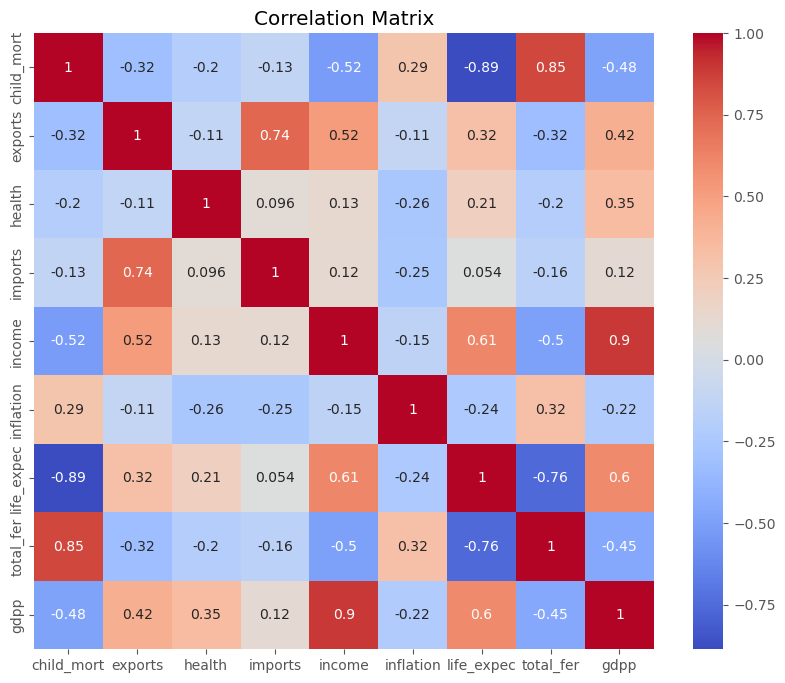

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

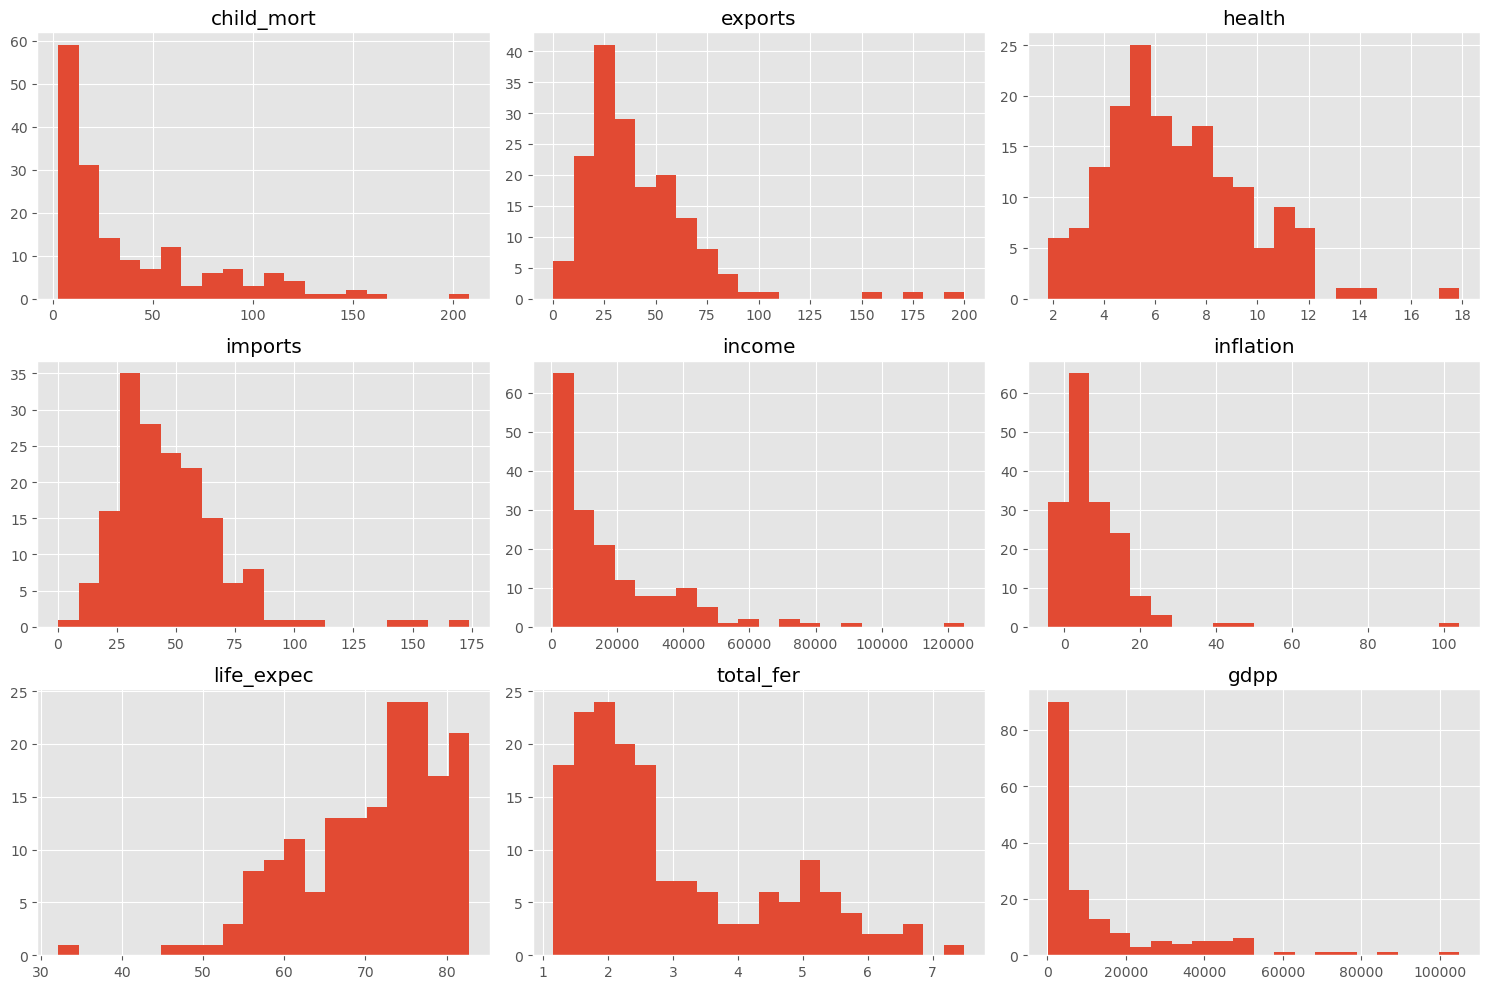

In [7]:
df.drop('country', axis=1).hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

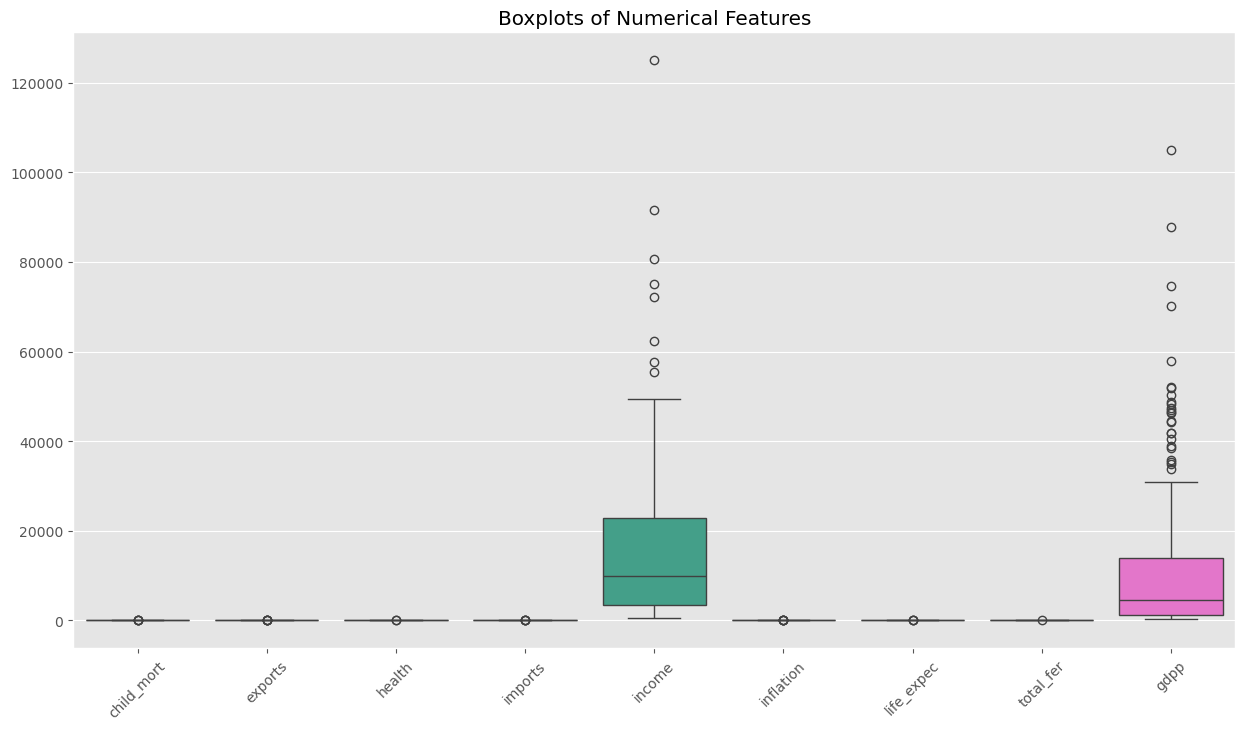

In [8]:
plt.figure(figsize=(15,8))

sns.boxplot(
    data=df.drop('country', axis=1)
)

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")

plt.show()


In [19]:
df.shape

(167, 10)

In [20]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

## 5. Feature Scaling

Since the dataset contains variables with different scales (income, GDP, life expectancy, etc.), feature scaling is applied to ensure all features contribute equally to clustering.

In [22]:
countries = df['country']

X = df.drop('country', axis=1)

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
X_scaled[:5]

array([[ 1.29153238, -1.13827979,  0.27908825, -0.08245496, -0.8082454 ,
         0.15733622, -1.61909203,  1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618,  0.07083669, -0.3753689 ,
        -0.31234747,  0.64786643, -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, -0.64176233, -0.22084447,
         0.78927429,  0.67042323, -0.0384044 , -0.46537561],
       [ 2.00780766,  0.77538117, -1.44807093, -0.16531531, -0.58504345,
         1.38705353, -1.17923442,  2.12815103, -0.51626829],
       [-0.69563412,  0.1606679 , -0.28689415,  0.4975675 ,  0.10173177,
        -0.60174853,  0.70425843, -0.54194633, -0.04181713]])

## 6. Finding Optimal Number of Clusters

The Elbow Method and Silhouette Score are used to determine the optimal number of clusters for K-Means clustering.

In [27]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

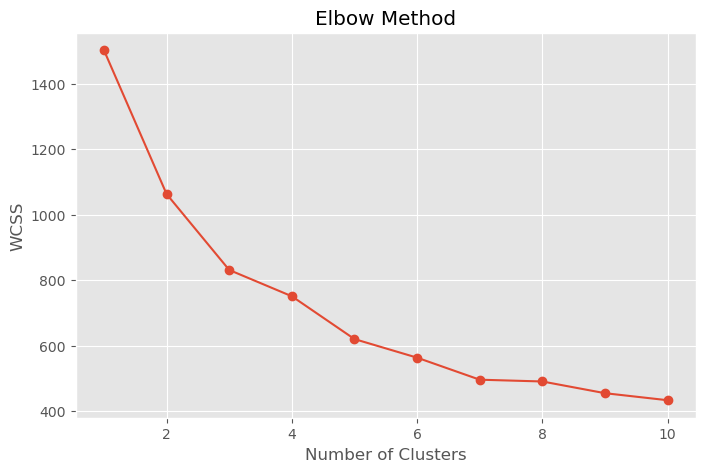

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [29]:
for k in range(2,8):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.266
K = 3, Silhouette Score = 0.286
K = 4, Silhouette Score = 0.288
K = 5, Silhouette Score = 0.301
K = 6, Silhouette Score = 0.236
K = 7, Silhouette Score = 0.248


## 7. K-Means Clustering

Based on the Silhouette Score analysis, K = 5 was selected as the optimal number of clusters. The K-Means algorithm was then applied to segment countries into distinct groups.

In [30]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [31]:
df['Cluster'] = clusters

In [32]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


## 8. PCA Visualization

Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset and visualize cluster separation in two dimensions.

In [33]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [34]:
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = clusters

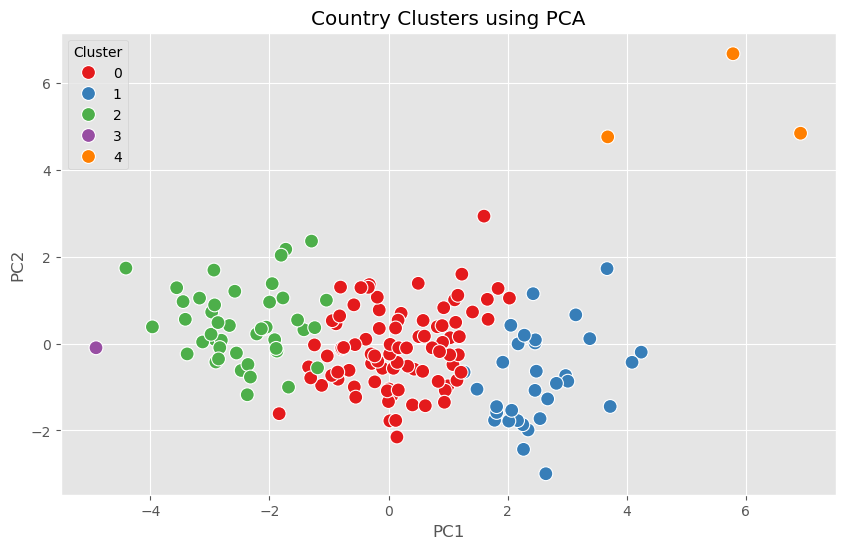

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Country Clusters using PCA")
plt.show()

## 9. Cluster Analysis

The average values of each feature are examined for every cluster to understand their socioeconomic characteristics.

In [36]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.219540,41.083782,6.246667,47.795010,12678.965517,7.727747,72.625287,2.333333,6494.390805
1,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000
2,94.313636,28.677500,6.329091,42.872727,3503.250000,9.895568,59.022727,5.047727,1753.909091
3,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000
4,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


In [37]:
df['Cluster'].value_counts()

Cluster
0    87
2    44
1    32
4     3
3     1
Name: count, dtype: int64

## 10. Countries Requiring Aid

Clusters with low GDP, low income, low life expectancy, and high child mortality were identified as priority groups for NGO intervention.

Cluster 3 represents the most critical countries, while Cluster 2 represents countries that also require significant developmental support.

In [38]:
critical_countries = df[df['Cluster'] == 3]

critical_countries[['country']]

,country
113,Nigeria


In [39]:
high_priority_countries = df[df['Cluster'] == 2]

high_priority_countries[['country']]

,country
0,Afghanistan
3,Angola
17,Benin
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic
32,Chad
36,Comoros
37,"Congo, Dem. Rep."


In [40]:
top_priority = df[
    (df['Cluster'] == 2) |
    (df['Cluster'] == 3)
]

top_priority = top_priority.sort_values(
    by=['gdpp', 'income']
)

top_priority[
    ['country',
     'income',
     'gdpp',
     'child_mort',
     'life_expec']
].head(15)

,country,income,gdpp,child_mort,life_expec
26,Burundi,764,231,93.6,57.7
88,Liberia,700,327,89.3,60.8
37,"Congo, Dem. Rep.",609,334,116.0,57.5
112,Niger,814,348,123.0,58.8
132,Sierra Leone,1220,399,160.0,55.0
93,Madagascar,1390,413,62.2,60.8
106,Mozambique,918,419,101.0,54.5
31,Central African Republic,888,446,149.0,47.5
94,Malawi,1030,459,90.5,53.1
50,Eritrea,1420,482,55.2,61.7


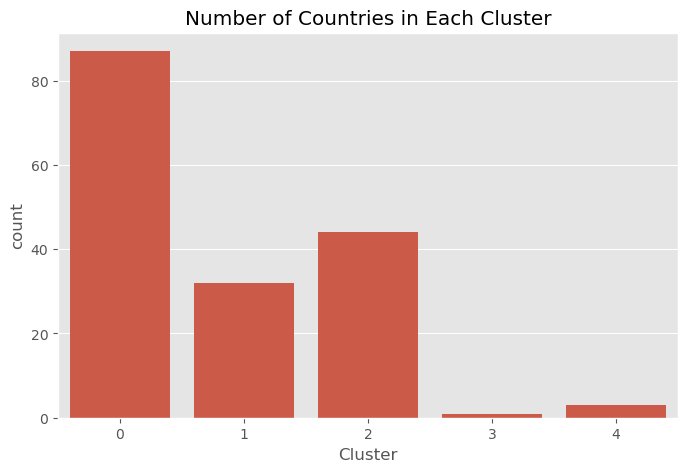

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title("Number of Countries in Each Cluster")
plt.show()

# Conclusion

The Country Data dataset was analyzed using K-Means clustering to segment countries based on socioeconomic and health-related indicators.

Data preprocessing included exploratory data analysis, feature scaling, and dimensionality reduction using Principal Component Analysis (PCA). The optimal number of clusters was selected using the Elbow Method and Silhouette Score, resulting in five clusters.

The clustering results revealed clear differences among country groups. Cluster 1 and Cluster 4 represented highly developed nations with high income levels, high GDP per capita, and long life expectancy. Cluster 0 represented developing economies with moderate socioeconomic indicators.

Cluster 2 contained a large group of countries characterized by low income, low GDP per capita, high child mortality, and lower life expectancy, indicating a strong need for economic and healthcare support.

Cluster 3 emerged as an extreme outlier consisting of a single country with exceptionally poor socioeconomic conditions and very high inflation, making it a critical case for intervention.

Overall, the clustering model successfully identified country groups with varying levels of development and can assist NGOs and policymakers in prioritizing aid allocation and development programs.

In [42]:
df['Cluster'].value_counts()

Cluster
0    87
2    44
1    32
4     3
3     1
Name: count, dtype: int64

In [43]:
df[df['Cluster'] == 3][['country']]

,country
113,Nigeria


In [44]:
df[df['Cluster'] == 4][['country']]

,country
91,Luxembourg
98,Malta
133,Singapore


In [45]:
cluster_summary[['income','gdpp','child_mort','life_expec']]

,income,gdpp,child_mort,life_expec
Cluster,,,,
0,12678.965517,6494.390805,22.219540,72.625287
1,44021.875000,42118.750000,5.181250,80.081250
2,3503.250000,1753.909091,94.313636,59.022727
3,5150.000000,2330.000000,130.000000,60.500000
4,64033.333333,57566.666667,4.133333,81.433333


### Key Observation

Cluster 3 contains only one country, Nigeria. This indicates that Nigeria behaves as an outlier in the dataset due to its exceptionally high child mortality rate, very high inflation, and relatively low GDP per capita.

Rather than representing a large country group, this cluster highlights a unique case requiring special attention from policymakers and aid organizations.

In [48]:
df[df['Cluster'] == 3][[
    'country',
    'child_mort',
    'income',
    'inflation',
    'life_expec',
    'gdpp'
]]

,country,child_mort,income,inflation,life_expec,gdpp
113,Nigeria,130.0,5150,104.0,60.5,2330


In [49]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("\nTotal Explained Variance:",
      pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.4595174  0.17181626]

Total Explained Variance: 0.6313336543771412


The first two principal components retain a substantial portion of the variance in the dataset, enabling effective visualization of country clusters in two dimensions.